In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
!cp -r /content/drive/MyDrive/train /content/
!cp -r /content/drive/MyDrive/eval /content/

In [26]:
!ls /content

drive  eval  sample_data  train


In [27]:
from pathlib import Path
from PIL import Image
import matplotlib.pylab as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
import torchvision.models as models
from tqdm import tqdm

In [28]:
DATA_ROOT = Path("/content")
TRAIN_PATH = DATA_ROOT/"train"
TEST_PATH=DATA_ROOT/"test"
EVAL_PATH=DATA_ROOT/"eval"

In [29]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [30]:
for folder in TRAIN_PATH.iterdir():
  print(folder.name)

glacier
street
sea
forest
buildings
mountain


In [31]:
train_images=list(TRAIN_PATH.rglob("*.jpg"))
print(f"The total number of train images are:{len(train_images)}")

The total number of train images are:14034


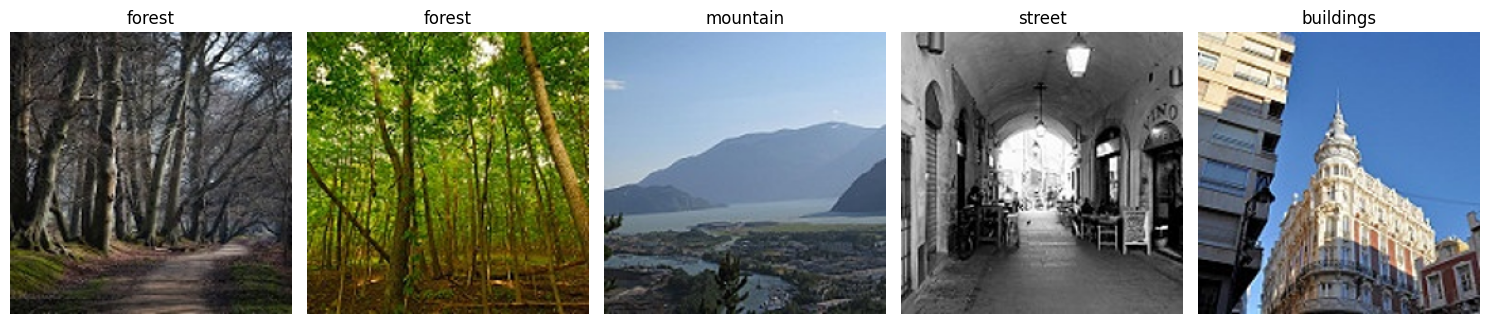

In [32]:
fig,axes=plt.subplots(1,5,figsize=(15,6))

for img in range(5):
  image=random.choice(train_images)
  image_path=image.parent.name
  image=Image.open(image).convert("RGB").resize((224,224))

  axes[img].imshow(image)
  axes[img].set_title(image_path)
  axes[img].axis('off')

plt.tight_layout()
plt.show()

In [33]:
class CustomDataset(Dataset):

  def __init__(self,root_path,transformation):
    super().__init__()
    self.root_path=Path(root_path)
    self.transformation=transformation
    self.labels=[]
    self.image_path=[]

    classes=["sea","glacier","forest","street","mountain","buildings"]

    for index,class_name in enumerate(classes):
      class_folder=self.root_path/class_name

      for img in class_folder.iterdir():
        if img.suffix.lower() in [".jpeg",".jpg",".png"]:
          self.image_path.append(img)
          self.labels.append(index)

  def __len__(self):
    return len(self.image_path)

  def __getitem__(self,index):
    image = Image.open(self.image_path[index]).convert("RGB")
    label=self.labels[index]

    if self.transformation:
      image=self.transformation(image)

    return image,label

In [34]:
vgg16=models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [35]:
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [36]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [37]:
for param in vgg16.features.parameters():
  param.requires_grad=False

In [38]:
vgg16.classifier=nn.Sequential(
    nn.Linear(25088,512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512,6)
)

In [39]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [40]:
train_data=CustomDataset(TRAIN_PATH,transform)
eval_data=CustomDataset(EVAL_PATH,transform)

In [41]:
train_dataloader=DataLoader(train_data,batch_size=128,shuffle=True,pin_memory=True,num_workers=2)
eval_dataloader=DataLoader(eval_data,batch_size=128,shuffle=False,pin_memory=True,num_workers=2)

In [42]:
epochs=10
learning_rate=1e-4
loss=nn.CrossEntropyLoss()
vgg16=vgg16.to(device)
optimizer=optim.Adam(vgg16.classifier.parameters(),lr=learning_rate,weight_decay=1e-4)

In [43]:
history={'train_loss':[],'train_accuracy':[],'eval_loss':[],'eval_accuracy':[]}

for epoch in range(epochs):
  vgg16.train()
  t_correct,t_loss,t_count=0,0,0
  for batch_feature,batch_label in tqdm(train_dataloader):
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
    optimizer.zero_grad()
    output=vgg16(batch_feature)
    model_loss=loss(output,batch_label)
    model_loss.backward()
    optimizer.step()

    # Calculate accuracy:
    _,predicted=torch.max(output,1)
    t_count+=batch_feature.shape[0]
    t_correct+=(predicted==batch_label).sum().item()
    t_loss+=model_loss.item()

  vgg16.eval()
  v_correct,v_loss,v_count=0,0,0
  with torch.no_grad():
      for batch_feature,batch_label in eval_dataloader:
        batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
        output=vgg16(batch_feature)
        model_loss=loss(output,batch_label)

        # Calculate accuracy:
        _,predicted=torch.max(output,1)
        v_count+=batch_feature.shape[0]
        v_correct+=(predicted==batch_label).sum().item()
        v_loss+=model_loss.item()

  history['train_loss'].append(t_loss/len(train_dataloader))
  history['eval_loss'].append(v_loss/len(eval_dataloader))
  history['train_accuracy'].append(t_correct/t_count)
  history['eval_accuracy'].append(v_correct/v_count)

  print(f"Epochs {epoch+1}  | Train Accuracy:{history['train_accuracy'][-1]:.2f} | Train Loss:{history['train_loss'][-1]:.2f} | Eval Accuracy:{history['eval_accuracy'][-1]:.2f} | Eval Loss:{history['eval_loss'][-1]:.2f}")

100%|██████████| 110/110 [01:07<00:00,  1.63it/s]


Epochs 1  | Train Accuracy:0.87 | Train Loss:0.37 | Eval Accuracy:0.91 | Eval Loss:0.26


100%|██████████| 110/110 [01:14<00:00,  1.47it/s]


Epochs 2  | Train Accuracy:0.92 | Train Loss:0.23 | Eval Accuracy:0.91 | Eval Loss:0.25


100%|██████████| 110/110 [01:14<00:00,  1.48it/s]


...

Epochs 8  | Train Accuracy:0.95 | Train Loss:0.13 | Eval Accuracy:0.91 | Eval Loss:0.24


100%|██████████| 110/110 [01:14<00:00,  1.48it/s]


Epochs 9  | Train Accuracy:0.95 | Train Loss:0.13 | Eval Accuracy:0.91 | Eval Loss:0.25


100%|██████████| 110/110 [01:14<00:00,  1.48it/s]


Epochs 10  | Train Accuracy:0.96 | Train Loss:0.12 | Eval Accuracy:0.92 | Eval Loss:0.25


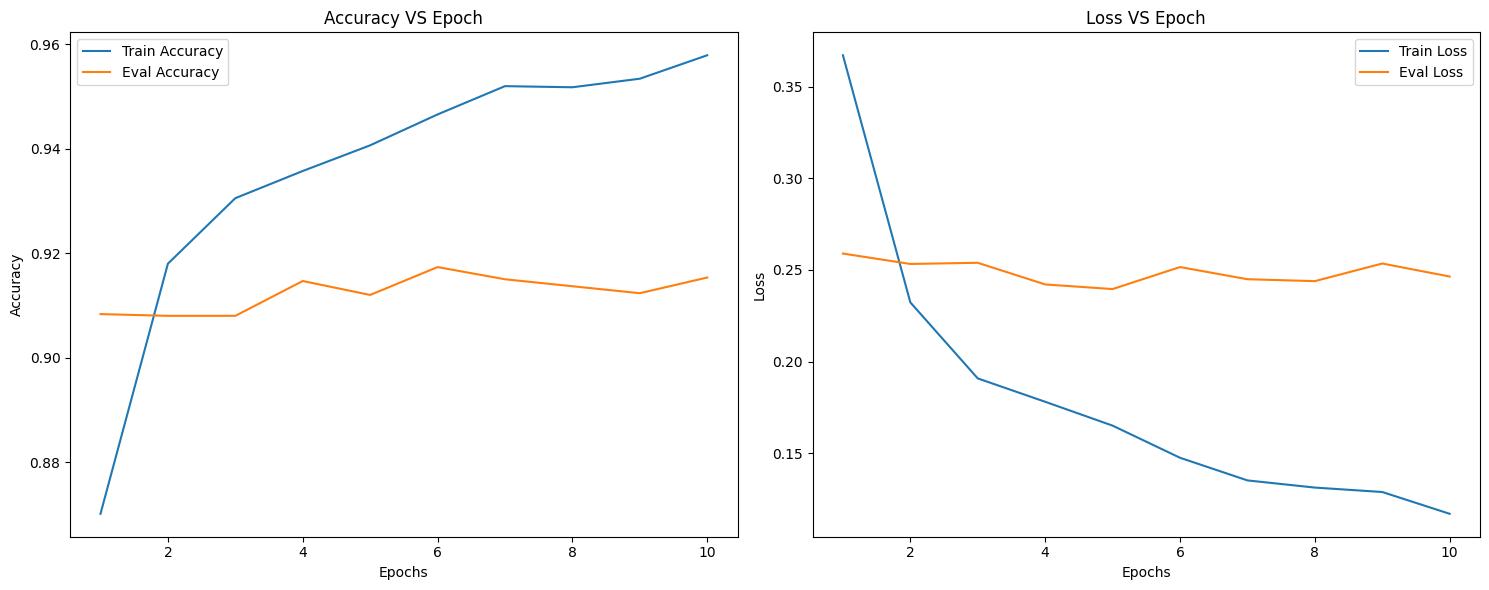

In [44]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

axes[0].plot(range(1,epochs+1),history['train_accuracy'],label="Train Accuracy")
axes[0].plot(range(1,epochs+1),history['eval_accuracy'],label="Eval Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy VS Epoch")
axes[0].legend()

axes[1].plot(range(1,epochs+1),history['train_loss'],label="Train Loss")
axes[1].plot(range(1,epochs+1),history['eval_loss'],label="Eval Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss VS Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [45]:
def predict_test_data(root_path):
  classes=["sea","glacier","forest","street","mountain","buildings"]
  fig,axes=plt.subplots(2,5,figsize=(15,6))
  # 1) Choose 10 image randomly
  vgg16.eval()
  img_list=list(root_path.rglob("*.jpg"))
  for img in range(10):
    image=random.choice(img_list)
    image=Image.open(image).convert("RGB")
    img_tensor=transform(image).unsqueeze(0).to(device)
  # 2) Send it to the model to predict
    with torch.no_grad():
      output=vgg16(img_tensor)

      _,predicted_index=torch.max(output,1)
      predicted_label=classes[predicted_index.item()]

      ax=axes[img//5,img%5]
      ax.imshow(image)
      ax.set_title(f"Guess: {predicted_label}")
      ax.axis('off')

  plt.tight_layout()
  plt.show()
  # 3) Since the test data doesnot have labels, your eyes are ground truth

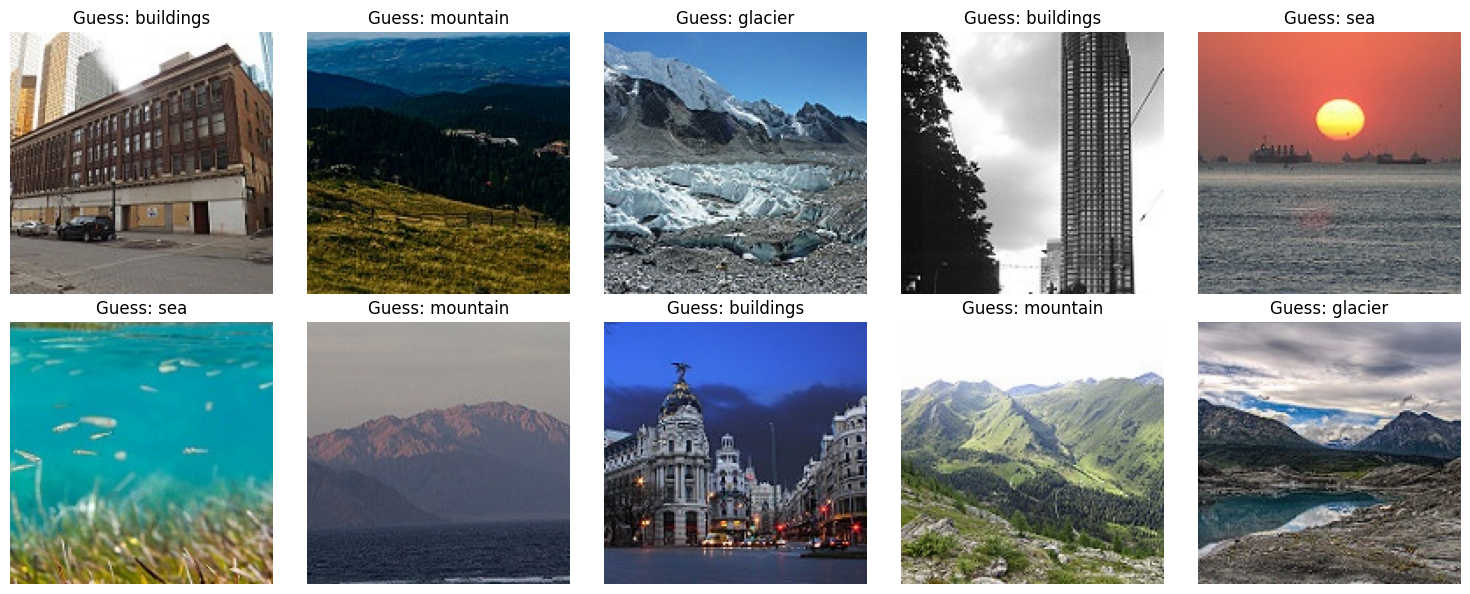

In [47]:
DATA_ROOT = Path("/content/drive/MyDrive")
TEST_PATH  = DATA_ROOT/"test"
predict_test_data(TEST_PATH)

Now we're introducing transfer learning with VGG16. The approach uses pretrained VGG16 for feature extraction (freeze `vgg16.features`) and replaces the classifier head for our specific task.

Pretrained models already excel at extracting low-level features like edges and textures from ImageNet. Fine-tuning only the classifier on our dataset leverages these learned representations instead of random initialization—providing a significant performance boost with less data and training time.